In [1]:
# importing required libs and reading the dataset

# base required libs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

import pandas as pd

# testing required libs
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.dummy import DummyRegressor

import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../dataset/store_location_dataset.csv')

In [2]:
# specifying the features and target (X and y) - splitting data into train and test with 80% train and 20% test size

features = ['dist_metro', 'num_residential', 'avg_income', 'traffic', 'rent_per_sqm', 'has_parking', 'competition_count']
X = df[features]
y = df['score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [3]:
# furthermore specifying the numerical and categorical features for making the preprocessor and scaling our data

numerical_features = ['dist_metro', 'num_residential', 'avg_income', 'rent_per_sqm', 'competition_count']
categorical_features = ['traffic', 'has_parking']

preprocessor = ColumnTransformer([
    ('numerical', StandardScaler(), numerical_features),
    ('categorical', OneHotEncoder(drop = 'first'), categorical_features)
])

In [4]:
# defining the model/pipeline and making the fit

model = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numerical', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [13]:
# making prediction

y_pred = model.predict(X_test)

In [37]:
# you can use this part of the code to edit and add new feature values for more understanding of how each value affects the target score/class

new_location = pd.DataFrame({
    'dist_metro' : [5],
    'num_residential' : [2],
    'avg_income' : [10],
    'traffic' : ['medium'],
    'rent_per_sqm' : [100],
    'has_parking' : ['yes'],
    'competition_count' : [3]
})
y_pred2 = model.predict(new_location)
print(f"Predicted score: {y_pred2[0]:.1f}")

predicted score: 70.2


📊 ارزیابی مدل رگرسیون خطی

✅ MAE  : 6.28
✅ MSE  : 64.13
✅ RMSE : 8.01
✅ R²   : 0.8536

🧱 Baseline (میانگین): R² = -0.0139
   ➜ بهبود R² نسبت به خط مبنا: 0.8675

🔍 تعداد پیش‌بینی‌های >100: 0  |  <0: 0

🔁 Cross-Validation R² (5-fold):
   میانگین: 0.8160
   انحراف معیار: 0.0214

📈 ضرایب مدل (اهمیت و جهت تأثیر):
          Feature  Coefficient
  has_parking_yes    15.913260
       dist_metro   -11.838932
      traffic_low    -9.045022
  num_residential     8.216536
       avg_income     5.267296
   traffic_medium     2.582391
     rent_per_sqm    -1.372776
competition_count    -1.197039

   🧠 تحلیل سریع:
      has_parking_yes               :  15.9133  ➕ مثبت (امتیاز را افزایش می‌دهد)
      dist_metro                    : -11.8389  ➖ منفی (امتیاز را کاهش می‌دهد)
      traffic_low                   :  -9.0450  ➖ منفی (امتیاز را کاهش می‌دهد)
      num_residential               :   8.2165  ➕ مثبت (امتیاز را افزایش می‌دهد)
      avg_income                    :   5.2673  ➕ مثبت (امتیاز را افزایش 

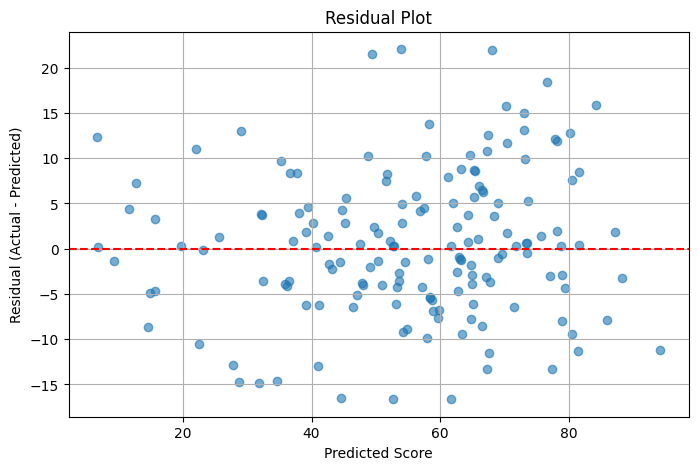


✅ تحلیل به پایان رسید.


In [29]:
# testing the model with certain techniques in order to see if the model is working fine or not and gaining stats (AI generated)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("📊 ارزیابی مدل رگرسیون خطی")
print("=" * 60)
print(f"\n✅ MAE  : {mae:.2f}")
print(f"✅ MSE  : {mse:.2f}")
print(f"✅ RMSE : {rmse:.2f}")
print(f"✅ R²   : {r2:.4f}")

# ---------- مقایسه با مدل پایه ----------
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
y_dummy_pred = dummy.predict(X_test)
r2_baseline = r2_score(y_test, y_dummy_pred)
print(f"\n🧱 Baseline (میانگین): R² = {r2_baseline:.4f}")
print(f"   ➜ بهبود R² نسبت به خط مبنا: {r2 - r2_baseline:.4f}")

# ---------- بررسی محدودهٔ پیش‌بینی‌ها ----------
over_100 = (y_pred > 100).sum()
under_0 = (y_pred < 0).sum()
print(f"\n🔍 تعداد پیش‌بینی‌های >100: {over_100}  |  <0: {under_0}")

# ---------- اعتبارسنجی متقابل ----------
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='r2')
print(f"\n🔁 Cross-Validation R² (5-fold):")
print(f"   میانگین: {cv_scores.mean():.4f}")
print(f"   انحراف معیار: {cv_scores.std():.4f}")

# ---------- ضرایب مدل ----------
enc = model.named_steps['preprocess'].named_transformers_['categorical']
cat_names = enc.get_feature_names_out(categorical_features)
all_features = numerical_features + list(cat_names)
coef = model.named_steps['regressor'].coef_
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coef})
coef_df['Abs'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs', ascending=False)

print("\n📈 ضرایب مدل (اهمیت و جهت تأثیر):")
print(coef_df[['Feature', 'Coefficient']].to_string(index=False))

print("\n   🧠 تحلیل سریع:")
for _, row in coef_df.iterrows():
    direction = "➕ مثبت (امتیاز را افزایش می‌دهد)" if row['Coefficient'] > 0 else "➖ منفی (امتیاز را کاهش می‌دهد)"
    print(f"      {row['Feature']:30s}: {row['Coefficient']:8.4f}  {direction}")

# ---------- نمودار باقی‌مانده‌ها ----------
plt.figure(figsize=(8,5))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Score')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

print("\n✅ تحلیل به پایان رسید.")